<a href="https://colab.research.google.com/github/Taniya1701/CSL701-CS06_Machine-Learning-Lab/blob/main/Experiments%20and%20Mini-Project/ML_Experiment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name : Taniya Anil Bhise   Roll No : CS06

### Aim : To implement a Bagging (Bootstrap Aggregating) ensemble classifier from scratch using Python, apply it to the Pima Indians Diabetes Database, and evaluate its performance against a single base classifier (Decision Tree)**.


## Objectives

1. Understand Ensemble Learning Principles: Comprehend how combining the predictions of multiple diverse models reduces overall model variance.
2. Master Bootstrapping: Implement random resampling of data with replacement from scratch to generate distinct training subsets.
3. Develop a Voting System: Build an aggregation mechanism (Majority Voting) from scratch to consolidate predictions.
4. Learn Baseline Evaluation: Compare the performance of a high-variance, low-bias single decision tree against the more stable Bagging ensemble.
5. Analyze Performance Metrics: Calculate and visualize classification metrics, including a Confusion Matrix, Accuracy, Precision, Recall, and ROC-AUC curve.


Relevant Theory
Ensemble Methods and Bagging
Ensemble learning combines several individual classifiers (base learners) to produce a unified model that generalizes better than any single model on unseen data. Bootstrap Aggregating (Bagging) is a parallel ensemble method designed primarily to reduce variance. High-variance models—such as deep, fully-grown decision trees—are highly sensitive to small changes in their training datasets. Bagging addresses this by smoothing out individual model errors without increasing bias.

The two core components of Bagging are:

1. Bootstrapping (Sampling with Replacement): For a training set of size $N$, we generate $B$ new datasets of the same size $N$. Each instance is selected at random from the original dataset with replacement. This means a single instance can be selected multiple times, while on average, only about 63.2% of the unique training samples are captured in each bootstrap, leaving the rest as out-of-bag (OOB) samples.
2. Aggregating (Majority Voting): A separate base learner $h_b(x)$ is trained independently on each bootstrap sample. For classification, predictions are aggregated by passing a test sample to all $B$ models and taking a majority vote: $$\hat{G}{\text{bag}}(x) = \text{argmax}{k} \sum_{b=1}^{B} I(h_b(x) = k)$$

An alternative to standard Bagging is subagging (subsample aggregating), where smaller training subsets (often $N/2$) are drawn without replacement to reduce correlation and accelerate computation.

---
## Software Requirements

- **Language:** Python 3.x

- **Core Libraries:**
  - **NumPy** for matrix manipulation and custom bootstrapping operations.
  - **Pandas** for loading, indexing, and cleaning tabular data.
  - **Matplotlib / Seaborn** for exploratory scatter plots, bar charts, and performance visualization.
  - **Scikit-learn** for train-test splitting, training individual base decision trees, and comparison with built-in Bagging algorithms.

---

## Dataset Information

The experiment utilizes the **Pima Indians Diabetes Database** from the UCI Machine Learning Repository. The dataset contains medical details for 768 female Pima Indian patients living in Arizona, categorized as either diabetic or non-diabetic.

- **Total Instances:** 768

- **Features (8 predictor variables):**
  1. **`Pregnancies`**: Number of times pregnant.
  2. **`Glucose`**: Plasma glucose concentration over 2 hours in an oral glucose tolerance test.
  3. **`BloodPressure`**: Diastolic blood pressure (mm Hg).
  4. **`SkinThickness`**: Triceps skin fold thickness (mm).
  5. **`Insulin`**: 2-Hour serum insulin ($\mu$U/ml).
  6. **`BMI`**: Body mass index (weight in kg/m$^2$).
  7. **`DiabetesPedigreeFunction`**: A function representing genetic predisposition.
  8. **`Age`**: Age of the subject in years.

- **Target Label (9th column):** **`Outcome`**
  - **0** represents non-diabetic.
  - **1** represents diabetic.

## Experimental Tasks

### Task 1: Environment Setup and Dataset Acquisition

**Goal:** Set up the workspace and load the data.

**Instructions:**

1. Import the necessary modules: **`numpy`**, **`pandas`**, **`matplotlib.pyplot`**, and **`sklearn`**.

2. Load the file **`pima-indians-diabetes.data`** into a Pandas DataFrame, assigning appropriate column headers.

3. Print the following:
   - First five records of the dataset.
   - Dataset shape, expected to be $768 \times 9$.
   - Data types of all features.
   - Descriptive statistics of the numeric features.

In [1]:
# ==========================================
# Task 1: Environment Setup and Dataset Acquisition
# ==========================================

# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

# ------------------------------------------
# Load the Pima Indians Diabetes Dataset
# ------------------------------------------

# Column names
columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

# Load dataset
df = pd.read_csv(
    "diabetes.csv",
    header=None,
    names=columns
)

# ------------------------------------------
# Display first five records
# ------------------------------------------

print("First five records of the dataset:")
display(df.head())

# ------------------------------------------
# Display dataset shape
# ------------------------------------------

print("\nDataset Shape:")
print(df.shape)

# ------------------------------------------
# Display data types
# ------------------------------------------

print("\nData Types:")
print(df.dtypes)

# ------------------------------------------
# Descriptive statistics
# ------------------------------------------

print("\nDescriptive Statistics:")
display(df.describe())

First five records of the dataset:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
1,6,148,72,35,169.5,33.6,0.627,50,1
2,1,85,66,29,102.5,26.6,0.351,31,0
3,8,183,64,32,169.5,23.3,0.672,32,1
4,1,89,66,23,94,28.1,0.167,21,0



Dataset Shape:
(769, 9)

Data Types:
Pregnancies                 object
Glucose                     object
BloodPressure               object
SkinThickness               object
Insulin                     object
BMI                         object
DiabetesPedigreeFunction    object
Age                         object
Outcome                     object
dtype: object

Descriptive Statistics:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,769,769,769,769,769,769,769,769,769
unique,18,136,48,51,188,248,518,53,3
top,1,100,70,27,102.5,30.1,0.258,22,0
freq,135,17,76,162,236,18,6,72,500


## Task 2: Exploratory Data Analysis (EDA)

**Goal:** Visually inspect feature distributions and class balance.

**Instructions:**

1. Calculate the **absolute count** and **percentage** of diabetic (`Outcome = 1`) and non-diabetic (`Outcome = 0`) cases. Plot the class balance using a **bar chart**.

2. Create a **scatter plot** of **`Age`** (Feature 7) against **`Glucose`** (Feature 1), color-coded according to the target variable **`Outcome`**.

3. Briefly explain why a simple linear decision boundary is insufficient to clearly separate the diabetic and non-diabetic classes.

Class Balance:


,Class,Count,Percentage
0,Non-Diabetic,500,65.104167
1,Diabetic,268,34.895833


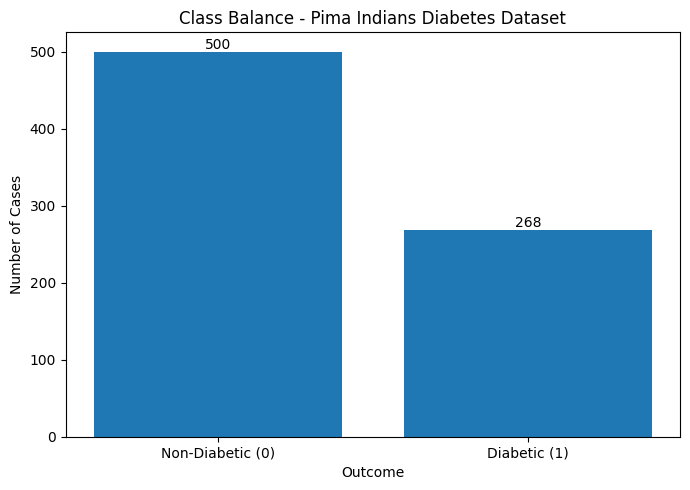

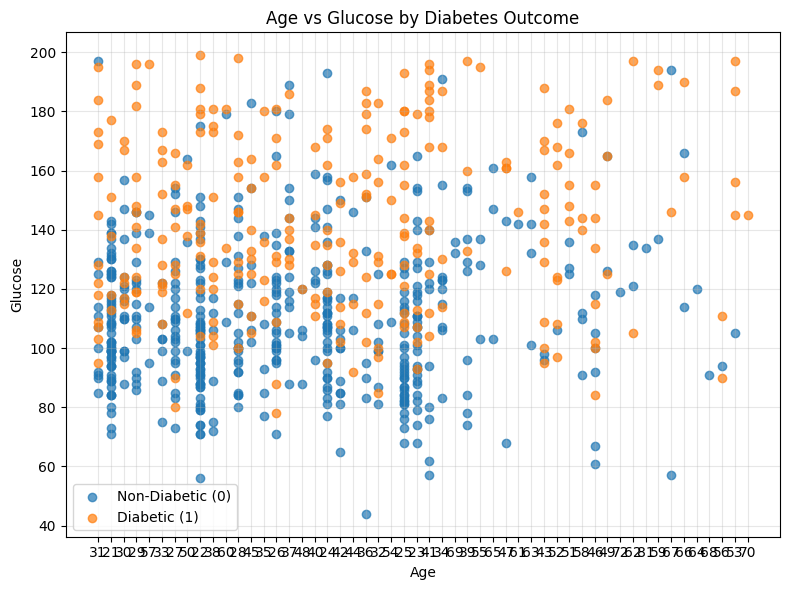


Explanation:

A simple linear decision boundary is insufficient to clearly separate
diabetic and non-diabetic classes because the two classes overlap in
the Age-Glucose feature space.

Patients of different outcomes can have similar Age and Glucose values.
Diabetes is also influenced by several other features such as BMI,
Pregnancies, Blood Pressure, Insulin, and Diabetes Pedigree Function.

Therefore, a single straight line cannot accurately separate all
diabetic and non-diabetic cases. A non-linear decision boundary or a
machine learning model such as a Decision Tree can better capture the
complex relationships among the features.



In [17]:
# ==========================================
# Task 2: Exploratory Data Analysis (EDA)
# ==========================================

# ------------------------------------------
# 1. Class Balance
# ------------------------------------------

# Calculate absolute counts
class_counts = df["Outcome"].value_counts().sort_index()

# Calculate percentages
class_percentages = (
    df["Outcome"].value_counts(normalize=True).sort_index() * 100
)

# Create a summary table
class_balance = pd.DataFrame({
    "Class": ["Non-Diabetic", "Diabetic"],
    "Count": class_counts.values,
    "Percentage": class_percentages.values
})

print("Class Balance:")
display(class_balance)


# ------------------------------------------
# Plot Class Balance using Bar Chart
# ------------------------------------------

plt.figure(figsize=(7, 5))

bars = plt.bar(
    ["Non-Diabetic (0)", "Diabetic (1)"],
    class_counts.values
)

plt.title("Class Balance - Pima Indians Diabetes Dataset")
plt.xlabel("Outcome")
plt.ylabel("Number of Cases")

# Display count on top of each bar
for bar, count in zip(bars, class_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(count),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


# ------------------------------------------
# 2. Scatter Plot: Age vs Glucose
# ------------------------------------------

plt.figure(figsize=(8, 6))

# Plot non-diabetic cases
plt.scatter(
    df[df["Outcome"] == 0]["Age"],
    df[df["Outcome"] == 0]["Glucose"],
    label="Non-Diabetic (0)",
    alpha=0.7
)

# Plot diabetic cases
plt.scatter(
    df[df["Outcome"] == 1]["Age"],
    df[df["Outcome"] == 1]["Glucose"],
    label="Diabetic (1)",
    alpha=0.7
)

plt.title("Age vs Glucose by Diabetes Outcome")
plt.xlabel("Age")
plt.ylabel("Glucose")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ------------------------------------------
# 3. Explanation
# ------------------------------------------

print("\nExplanation:")
print("""
A simple linear decision boundary is insufficient to clearly separate
diabetic and non-diabetic classes because the two classes overlap in
the Age-Glucose feature space.

Patients of different outcomes can have similar Age and Glucose values.
Diabetes is also influenced by several other features such as BMI,
Pregnancies, Blood Pressure, Insulin, and Diabetes Pedigree Function.

Therefore, a single straight line cannot accurately separate all
diabetic and non-diabetic cases. A non-linear decision boundary or a
machine learning model such as a Decision Tree can better capture the
complex relationships among the features.
""")

#### **Task 3: Preprocessing and Handling Missing Values**

**Goal:** Handle anomalies and prepare numerical features for further analysis.

**Instructions:**

1. Identify the features where a value of \(0\) is physically impossible:
   \[
   \{\text{Glucose},\text{BloodPressure},\text{SkinThickness},
   \text{Insulin},\text{BMI}\}
   \]

2. Replace all invalid \(0\) values in these features with \(\mathrm{NaN}\).

3. Handle the resulting missing values by:
   - imputing them using the **mean** or **median** of the respective feature, or
   - dropping rows containing missing values to maintain numerical consistency.

In [21]:
# ==========================================
# Task 3: Preprocessing and Handling Missing Values
# ==========================================

# ------------------------------------------
# 1. Identify Features Where 0 is Invalid
# ------------------------------------------

invalid_zero_features = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

print("Features where 0 is physically impossible:")
print(invalid_zero_features)


# ------------------------------------------
# 2. Replace Invalid 0 Values with NaN
# ------------------------------------------

# Count invalid zero values before replacement
print("\nNumber of invalid 0 values before replacement:")

for feature in invalid_zero_features:
    count = (df[feature] == 0).sum()
    print(f"{feature}: {count}")


# Replace 0 with NaN
df[invalid_zero_features] = df[invalid_zero_features].replace(0, np.nan)


# ------------------------------------------
# Check Missing Values After Replacement
# ------------------------------------------

print("\nMissing values after replacing 0 with NaN:")
print(df[invalid_zero_features].isnull().sum())


# ------------------------------------------
# 3. Handle Missing Values using Median
# ------------------------------------------

# Calculate median of each feature
medians = df[invalid_zero_features].median()

print("\nMedian values used for imputation:")
display(medians.to_frame(name="Median"))


# Fill missing values with respective feature median
df[invalid_zero_features] = df[invalid_zero_features].fillna(medians)


# ------------------------------------------
# Verify Missing Values
# ------------------------------------------

print("\nMissing values after median imputation:")
print(df[invalid_zero_features].isnull().sum())


# ------------------------------------------
# Display Dataset After Preprocessing
# ------------------------------------------

print("\nFirst five records after preprocessing:")
display(df.head())


# ------------------------------------------
# Final Dataset Information
# ------------------------------------------

print("\nFinal Dataset Shape:")
print(df.shape)

print("\nFinal Data Types:")
print(df.dtypes)

Features where 0 is physically impossible:
['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

Number of invalid 0 values before replacement:
Glucose: 0
BloodPressure: 0
SkinThickness: 0
Insulin: 0
BMI: 0

Missing values after replacing 0 with NaN:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

Median values used for imputation:


,Median
Glucose,117.00
BloodPressure,72.00
SkinThickness,28.00
Insulin,102.50
BMI,32.05



Missing values after median imputation:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

First five records after preprocessing:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,169.5,33.6,0.627,50,1
1,1,85.0,66.0,29.0,102.5,26.6,0.351,31,0
2,8,183.0,64.0,32.0,169.5,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1



Final Dataset Shape:
(768, 9)

Final Data Types:
Pregnancies                  object
Glucose                     float64
BloodPressure               float64
SkinThickness               float64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction     object
Age                          object
Outcome                       int64
dtype: object


#### **Task 4: Stratified Train-Test Splitting**

**Goal:** Divide the data while preserving class proportions.

**Instructions:**

1. Isolate the feature matrix \(X\) and the target vector \(y\):
   \[
   X = \text{first 8 columns}
   \]
   \[
   y = \text{9th column}
   \]

2. Split the dataset into:
   \[
   \text{Training Data} = 80\%
   \]
   \[
   \text{Test Data} = 20\%
   \]

   Use **stratified sampling** to ensure that the class proportions in the target variable \(y\) are preserved in both the training and test datasets.

In [23]:
# ==========================================
# Task 4: Stratified Train-Test Splitting
# ==========================================

# ------------------------------------------
# 1. Separate Features (X) and Target (y)
# ------------------------------------------

# X = first 8 columns (features)
X = df.iloc[:, :8]

# y = 9th column (target)
y = df.iloc[:, 8]

print("Feature Matrix (X) Shape:")
print(X.shape)

print("\nTarget Vector (y) Shape:")
print(y.shape)


# ------------------------------------------
# 2. Stratified Train-Test Split
# ------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# ------------------------------------------
# Display Dataset Sizes
# ------------------------------------------

print("\nTraining and Testing Dataset Sizes:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


# ------------------------------------------
# 3. Check Class Proportions
# ------------------------------------------

print("\nClass Distribution in Original Dataset:")
print(y.value_counts(normalize=True) * 100)

print("\nClass Distribution in Training Dataset:")
print(y_train.value_counts(normalize=True) * 100)

print("\nClass Distribution in Test Dataset:")
print(y_test.value_counts(normalize=True) * 100)


# ------------------------------------------
# 4. Display Absolute Class Counts
# ------------------------------------------

print("\nTraining Class Counts:")
print(y_train.value_counts().sort_index())

print("\nTest Class Counts:")
print(y_test.value_counts().sort_index())

Feature Matrix (X) Shape:
(768, 8)

Target Vector (y) Shape:
(768,)

Training and Testing Dataset Sizes:
X_train: (614, 8)
X_test : (154, 8)
y_train: (614,)
y_test : (154,)

Class Distribution in Original Dataset:
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64

Class Distribution in Training Dataset:
Outcome
0    65.14658
1    34.85342
Name: proportion, dtype: float64

Class Distribution in Test Dataset:
Outcome
0    64.935065
1    35.064935
Name: proportion, dtype: float64

Training Class Counts:
Outcome
0    400
1    214
Name: count, dtype: int64

Test Class Counts:
Outcome
0    100
1     54
Name: count, dtype: int64


#### **Task 5: Custom Bootstrap Sampling Function**

**Goal:** Implement the sampling-with-replacement mechanism.

**Instructions:**

1. Write a custom Python function \(\texttt{get\_bootstrap\_sample}(X, y)\) using NumPy's random generation tools, such as:
   \[
   \texttt{np.random.choice}
   \quad \text{or} \quad
   \texttt{np.random.randint}
   \]

2. The function must return a resampled feature matrix \(X^*\) and target vector \(y^*\) of the same size \(N\) as the training set:
   \[
   |X^*| = |y^*| = N
   \]
   
   Sampling should be performed **with replacement**, allowing duplicate rows to appear in the bootstrap sample.

3. Verify that the function works correctly by demonstrating that:
   - Some original row indices are **duplicated** in the bootstrap sample.
   - Some original row indices are **omitted**, forming the **Out-of-Bag (OOB)** samples.

In [24]:
# ==========================================
# Task 5: Custom Bootstrap Sampling Function
# ==========================================

# ------------------------------------------
# 1. Define Bootstrap Sampling Function
# ------------------------------------------

def get_bootstrap_sample(X, y):
    """
    Creates a bootstrap sample from the training data.

    Sampling is performed with replacement, so:
    - Duplicate rows can appear.
    - Some original rows may be omitted (OOB samples).

    Returns:
        X_bootstrap : Resampled feature matrix
        y_bootstrap : Resampled target vector
        sample_indices : Original indices selected
    """

    # Number of training samples
    N = len(X)

    # Generate random indices with replacement
    sample_indices = np.random.choice(
        N,
        size=N,
        replace=True
    )

    # Create bootstrap samples
    X_bootstrap = X.iloc[sample_indices].reset_index(drop=True)
    y_bootstrap = y.iloc[sample_indices].reset_index(drop=True)

    return X_bootstrap, y_bootstrap, sample_indices


# ------------------------------------------
# 2. Generate Bootstrap Sample
# ------------------------------------------

# Set seed for reproducibility
np.random.seed(42)

X_bootstrap, y_bootstrap, sample_indices = get_bootstrap_sample(
    X_train,
    y_train
)


# ------------------------------------------
# 3. Verify Bootstrap Sample Size
# ------------------------------------------

print("Original Training Set Size:")
print(len(X_train))

print("\nBootstrap Sample Size:")
print(len(X_bootstrap))

print("\nX_bootstrap Shape:")
print(X_bootstrap.shape)

print("\ny_bootstrap Shape:")
print(y_bootstrap.shape)


# ------------------------------------------
# 4. Check Duplicate Row Indices
# ------------------------------------------

unique_indices, counts = np.unique(
    sample_indices,
    return_counts=True
)

duplicate_indices = unique_indices[counts > 1]

print("\nNumber of unique rows selected:")
print(len(unique_indices))

print("\nNumber of duplicated original indices:")
print(len(duplicate_indices))

print("\nSome duplicated original indices:")
print(duplicate_indices[:10])


# ------------------------------------------
# 5. Identify Out-of-Bag (OOB) Samples
# ------------------------------------------

# All original training indices
all_indices = np.arange(len(X_train))

# Indices not selected in the bootstrap sample
oob_indices = np.setdiff1d(
    all_indices,
    unique_indices
)

print("\nNumber of OOB samples:")
print(len(oob_indices))

print("\nSome OOB original indices:")
print(oob_indices[:10])


# ------------------------------------------
# 6. Verify the Bootstrap Properties
# ------------------------------------------

print("\n==========================================")
print("Bootstrap Sampling Verification")
print("==========================================")

print("Original training samples :", len(X_train))
print("Bootstrap samples         :", len(X_bootstrap))
print("Unique selected samples   :", len(unique_indices))
print("Duplicated samples        :", len(duplicate_indices))
print("OOB samples               :", len(oob_indices))

if len(duplicate_indices) > 0:
    print("\n✓ Duplicate rows are present in the bootstrap sample.")
else:
    print("\n✗ No duplicate rows found.")

if len(oob_indices) > 0:
    print("✓ Some original rows were omitted and are OOB samples.")
else:
    print("✗ No OOB samples found.")

Original Training Set Size:
614

Bootstrap Sample Size:
614

X_bootstrap Shape:
(614, 8)

y_bootstrap Shape:
(614,)

Number of unique rows selected:
377

Number of duplicated original indices:
164

Some duplicated original indices:
[ 1  4  8 11 14 20 21 27 32 34]

Number of OOB samples:
237

Some OOB original indices:
[ 2  3  5  6 10 12 23 25 29 30]

Bootstrap Sampling Verification
Original training samples : 614
Bootstrap samples         : 614
Unique selected samples   : 377
Duplicated samples        : 164
OOB samples               : 237

✓ Duplicate rows are present in the bootstrap sample.
✓ Some original rows were omitted and are OOB samples.


#### **Task 6: Growing the Ensemble of Base Classifiers**

**Goal:** Programmatically train diverse base learners.

**Instructions:**

1. Initialize an empty list to store the trained models and choose the number of bootstrap iterations, for example:
   \[
   B = 50
   \]

2. Execute the following steps for \(B\) iterations:

   - Generate a unique bootstrap training dataset:
     \[
     (X^{*b}, y^{*b})
     \]
     using the bootstrap sampling function from **Task 5**.

   - Instantiate a Scikit-Learn `DecisionTreeClassifier` with:
     \[
     \texttt{max\_depth=None}
     \]
     This ensures that the decision trees are **fully grown**, resulting in high-variance base learners.

   - Fit the decision tree on the bootstrapped training subset:
     \[
     \text{Model}_b.fit(X^{*b}, y^{*b})
     \]

   - Append the trained model to the ensemble list.

3. After completing all \(B\) iterations, the ensemble should contain:
   \[
   B = 50
   \]
   independently trained decision trees.

In [36]:
# ==========================================
# Task 6: Growing the Ensemble of Base Classifiers
# ==========================================

# ------------------------------------------
# 1. Initialize Ensemble
# ------------------------------------------

# Number of bootstrap iterations / base learners
B = 50

# Empty list to store trained decision trees
ensemble = []


# ------------------------------------------
# 2. Train B Decision Trees
# ------------------------------------------

# Set random seed for reproducibility
np.random.seed(42)

for b in range(B):

    # Generate a unique bootstrap training dataset
    X_bootstrap, y_bootstrap, sample_indices = get_bootstrap_sample(
        X_train,
        y_train
    )

    # Create a fully grown Decision Tree
    model = DecisionTreeClassifier(
        max_depth=None,
        random_state=b
    )

    # Train the model on the bootstrap sample
    model.fit(X_bootstrap, y_bootstrap)

    # Add the trained model to the ensemble
    ensemble.append(model)


# ------------------------------------------
# 3. Verify the Ensemble
# ------------------------------------------

print("Ensemble Training Completed!")
print("------------------------------------------")
print("Number of bootstrap iterations (B):", B)
print("Number of trained models:", len(ensemble))

# Verify that all models are Decision Trees
print("\nModel types:")
for i, model in enumerate(ensemble[:5], start=1):
    print(f"Model {i}: {type(model).__name__}")

print("\n✓ The ensemble contains", len(ensemble),
      "independently trained Decision Tree classifiers.")

Ensemble Training Completed!
------------------------------------------
Number of bootstrap iterations (B): 50
Number of trained models: 50

Model types:
Model 1: DecisionTreeClassifier
Model 2: DecisionTreeClassifier
Model 3: DecisionTreeClassifier
Model 4: DecisionTreeClassifier
Model 5: DecisionTreeClassifier

✓ The ensemble contains 50 independently trained Decision Tree classifiers.


#### **Task 7: Implementing Aggregation (Majority Voting) from Scratch**

**Goal:** Consolidate individual model decisions using majority voting.

**Instructions:**

1. Write a custom function:
   \[
   \texttt{custom\_bagging\_predict(ensemble, X\_test)}
   \]
   to generate the final predictions.

2. For each sample in \(X_{\text{test}}\), collect the predictions generated by all \(B\) decision trees in the ensemble:
   \[
   \hat{y}_1,\hat{y}_2,\ldots,\hat{y}_B
   \]

3. Apply a **majority voting** rule to determine the final predicted class. The class with the highest number of votes is selected:
   \[
   \hat{y} =
   \underset{c \in \{0,1\}}{\arg\max}
   \sum_{b=1}^{B} I(\hat{y}_b=c)
   \]

   where \(I(\cdot)\) is an indicator function.

4. The final prediction for each test sample must therefore be either:
   \[
   \hat{y} \in \{0,1\}
   \]

5. The function should return the final majority-voted predictions for all samples in \(X_{\text{test}}\).

In [38]:
# ==========================================
# Task 7: Implementing Aggregation
#          (Majority Voting) from Scratch
# ==========================================

# ------------------------------------------
# 1. Define Custom Bagging Prediction
# ------------------------------------------

def custom_bagging_predict(ensemble, X_test):
    """
    Generate final predictions using majority voting
    from all decision trees in the ensemble.

    Parameters:
        ensemble : list
            List of trained Decision Tree classifiers.

        X_test : pandas.DataFrame
            Test feature matrix.

    Returns:
        final_predictions : numpy.ndarray
            Majority-voted predictions (0 or 1).
    """

    # Store predictions from every tree
    all_predictions = []

    # Get predictions from each decision tree
    for model in ensemble:
        predictions = model.predict(X_test)
        all_predictions.append(predictions)

    # Convert list to NumPy array
    # Shape: (B, number_of_test_samples)
    all_predictions = np.array(all_predictions)

    # ------------------------------------------
    # Majority Voting
    # ------------------------------------------

    final_predictions = []

    # Process each test sample
    for i in range(all_predictions.shape[1]):

        # Get votes from all trees for this sample
        votes = all_predictions[:, i]

        # Count votes for class 0
        votes_class_0 = np.sum(votes == 0)

        # Count votes for class 1
        votes_class_1 = np.sum(votes == 1)

        # Select class with the highest number of votes
        if votes_class_1 > votes_class_0:
            final_predictions.append(1)
        else:
            final_predictions.append(0)

    # Convert final predictions to NumPy array
    final_predictions = np.array(final_predictions)

    return final_predictions


# ------------------------------------------
# 2. Generate Final Test Predictions
# ------------------------------------------

y_pred = custom_bagging_predict(
    ensemble,
    X_test
)


# ------------------------------------------
# 3. Verify Predictions
# ------------------------------------------

print("Majority Voting Completed!")
print("------------------------------------------")

print("Number of test samples:", len(X_test))
print("Number of predictions:", len(y_pred))

print("\nFirst 20 predictions:")
print(y_pred[:20])

print("\nUnique predicted classes:")
print(np.unique(y_pred))


# ------------------------------------------
# 4. Verify that Predictions are Only 0 or 1
# ------------------------------------------

if np.all(np.isin(y_pred, [0, 1])):
    print("\n✓ All predictions are valid classes: 0 or 1.")
else:
    print("\n✗ Invalid class detected.")

Majority Voting Completed!
------------------------------------------
Number of test samples: 154
Number of predictions: 154

First 20 predictions:
[0 0 0 1 0 0 1 1 0 1 0 1 0 0 1 1 0 0 1 0]

Unique predicted classes:
[0 1]

✓ All predictions are valid classes: 0 or 1.


#### **Task 8: Single Classifier vs. Bagging Performance Comparison**

- **Goal:** Observe the variance-reduction benefits of ensembling.

- **Instructions:**
  1. Train a standalone, single \(\texttt{DecisionTreeClassifier}\) (fully grown, no depth limit) on the original, un-resampled training data.
  2. Predict the classes for \(X_{\text{test}}\) using both the single tree and your custom Bagging classifier.
  3. Construct a **Confusion Matrix** for both models.
  4. Compute and print **Accuracy, Precision, Recall, and F1-Score** for both models, demonstrating how Bagging stabilizes results and reduces error rates.

Confusion Matrix - Single Decision Tree:


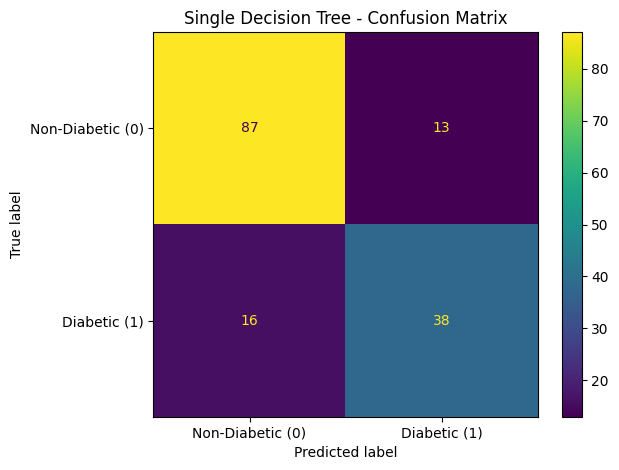

Confusion Matrix - Custom Bagging:


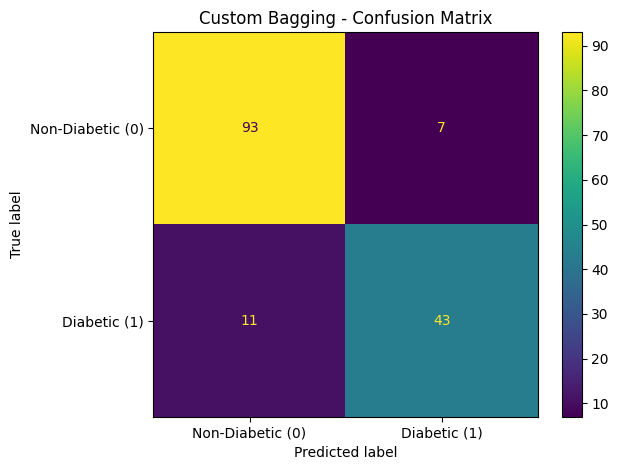


Performance Comparison


,Metric,Single Decision Tree,Custom Bagging
0,Accuracy,81.17,88.31
1,Precision,74.51,86.00
2,Recall,70.37,79.63
3,F1-Score,72.38,82.69



Single Decision Tree:
Accuracy  : 0.8117
Precision : 0.7451
Recall    : 0.7037
F1-Score  : 0.7238

Custom Bagging:
Accuracy  : 0.8831
Precision : 0.8600
Recall    : 0.7963
F1-Score  : 0.8269

Bagging Improvement
Accuracy improvement  : 7.14%
Precision improvement : 11.49%
Recall improvement    : 9.26%
F1-Score improvement  : 10.31%


In [48]:
# ==========================================
# Task 8: Single Classifier vs. Bagging
# Performance Comparison
# ==========================================

from sklearn.metrics import f1_score

# ------------------------------------------
# 1. Train a Single Decision Tree
# ------------------------------------------

single_tree = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

# Train on the original, non-resampled training data
single_tree.fit(X_train, y_train)


# ------------------------------------------
# 2. Generate Predictions
# ------------------------------------------

# Prediction using the single Decision Tree
y_pred_single = single_tree.predict(X_test)

# Prediction using the custom Bagging classifier
y_pred_bagging = custom_bagging_predict(
    ensemble,
    X_test
)


# ------------------------------------------
# 3. Confusion Matrices
# ------------------------------------------

cm_single = confusion_matrix(
    y_test,
    y_pred_single
)

cm_bagging = confusion_matrix(
    y_test,
    y_pred_bagging
)


# ------------------------------------------
# Display Confusion Matrix - Single Tree
# ------------------------------------------

print("Confusion Matrix - Single Decision Tree:")

disp_single = ConfusionMatrixDisplay(
    confusion_matrix=cm_single,
    display_labels=["Non-Diabetic (0)", "Diabetic (1)"]
)

disp_single.plot()
plt.title("Single Decision Tree - Confusion Matrix")
plt.tight_layout()
plt.show()


# ------------------------------------------
# Display Confusion Matrix - Bagging
# ------------------------------------------

print("Confusion Matrix - Custom Bagging:")

disp_bagging = ConfusionMatrixDisplay(
    confusion_matrix=cm_bagging,
    display_labels=["Non-Diabetic (0)", "Diabetic (1)"]
)

disp_bagging.plot()
plt.title("Custom Bagging - Confusion Matrix")
plt.tight_layout()
plt.show()


# ------------------------------------------
# 4. Calculate Performance Metrics
# ------------------------------------------

# Single Decision Tree metrics
accuracy_single = accuracy_score(y_test, y_pred_single)

precision_single = precision_score(
    y_test,
    y_pred_single,
    zero_division=0
)

recall_single = recall_score(
    y_test,
    y_pred_single,
    zero_division=0
)

f1_single = f1_score(
    y_test,
    y_pred_single,
    zero_division=0
)


# Bagging metrics
accuracy_bagging = accuracy_score(
    y_test,
    y_pred_bagging
)

precision_bagging = precision_score(
    y_test,
    y_pred_bagging,
    zero_division=0
)

recall_bagging = recall_score(
    y_test,
    y_pred_bagging,
    zero_division=0
)

f1_bagging = f1_score(
    y_test,
    y_pred_bagging,
    zero_division=0
)


# ------------------------------------------
# 5. Create Performance Comparison Table
# ------------------------------------------

comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    "Single Decision Tree": [
        accuracy_single,
        precision_single,
        recall_single,
        f1_single
    ],
    "Custom Bagging": [
        accuracy_bagging,
        precision_bagging,
        recall_bagging,
        f1_bagging
    ]
})

# Convert scores to percentages
comparison["Single Decision Tree"] = (
    comparison["Single Decision Tree"] * 100
)

comparison["Custom Bagging"] = (
    comparison["Custom Bagging"] * 100
)

# Round values
comparison["Single Decision Tree"] = comparison[
    "Single Decision Tree"
].round(2)

comparison["Custom Bagging"] = comparison[
    "Custom Bagging"
].round(2)


# ------------------------------------------
# 6. Display Results
# ------------------------------------------

print("\n==========================================")
print("Performance Comparison")
print("==========================================")

display(comparison)


# ------------------------------------------
# 7. Print Individual Results
# ------------------------------------------

print("\nSingle Decision Tree:")
print(f"Accuracy  : {accuracy_single:.4f}")
print(f"Precision : {precision_single:.4f}")
print(f"Recall    : {recall_single:.4f}")
print(f"F1-Score  : {f1_single:.4f}")

print("\nCustom Bagging:")
print(f"Accuracy  : {accuracy_bagging:.4f}")
print(f"Precision : {precision_bagging:.4f}")
print(f"Recall    : {recall_bagging:.4f}")
print(f"F1-Score  : {f1_bagging:.4f}")


# ------------------------------------------
# 8. Compare Improvement
# ------------------------------------------

print("\n==========================================")
print("Bagging Improvement")
print("==========================================")

print(
    f"Accuracy improvement  : "
    f"{(accuracy_bagging - accuracy_single) * 100:.2f}%"
)

print(
    f"Precision improvement : "
    f"{(precision_bagging - precision_single) * 100:.2f}%"
)

print(
    f"Recall improvement    : "
    f"{(recall_bagging - recall_single) * 100:.2f}%"
)

print(
    f"F1-Score improvement  : "
    f"{(f1_bagging - f1_single) * 100:.2f}%"
)

#### **Task 9: ROC-AUC Analysis and Curve Visualization**

- **Goal:** Measure classification performance at different thresholds.

- **Instructions:**
  1. Calculate predicted class probabilities by averaging the probability estimates (\(\texttt{predict\_proba}\)) across all \(B\) decision trees in your custom Bagging model.
  2. Plot the **Receiver Operating Characteristic (ROC) curve** for both the single decision tree and the custom Bagging model on a single chart.
  3. Compute and contrast the **Area Under the Curve (AUC)** for both configurations, noting the improvement.

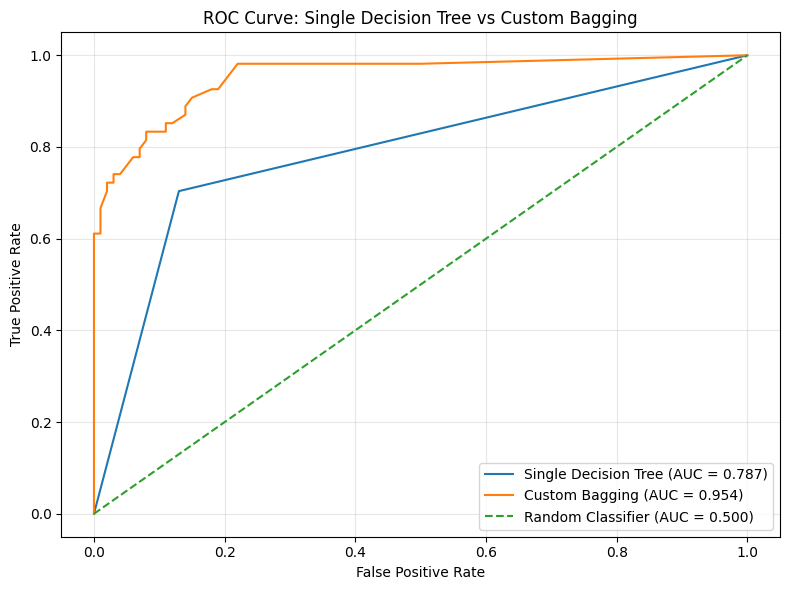

ROC-AUC Results
Single Decision Tree AUC : 0.7869
Custom Bagging AUC       : 0.9539

AUC Improvement          : 0.1670
✓ Bagging improved the AUC compared with the single Decision Tree.


In [52]:
# ==========================================
# Task 9: ROC-AUC Analysis and Curve Visualization
# ==========================================

# ------------------------------------------
# 1. Single Decision Tree Probabilities
# ------------------------------------------

# Probability of the positive class (Outcome = 1)
y_prob_single = single_tree.predict_proba(X_test)[:, 1]


# ------------------------------------------
# 2. Bagging Probability Estimates
# ------------------------------------------

# Store probability predictions from every tree
all_probabilities = []

for model in ensemble:
    # Probability for class 1
    probabilities = model.predict_proba(X_test)[:, 1]
    all_probabilities.append(probabilities)

# Convert to NumPy array
# Shape = (50, number_of_test_samples)
all_probabilities = np.array(all_probabilities)

# Average probability across all 50 decision trees
y_prob_bagging = np.mean(
    all_probabilities,
    axis=0
)


# ------------------------------------------
# 3. Calculate ROC Curves
# ------------------------------------------

# ROC for Single Decision Tree
fpr_single, tpr_single, thresholds_single = roc_curve(
    y_test,
    y_prob_single
)

# ROC for Custom Bagging
fpr_bagging, tpr_bagging, thresholds_bagging = roc_curve(
    y_test,
    y_prob_bagging
)


# ------------------------------------------
# 4. Calculate AUC
# ------------------------------------------

auc_single = roc_auc_score(
    y_test,
    y_prob_single
)

auc_bagging = roc_auc_score(
    y_test,
    y_prob_bagging
)


# ------------------------------------------
# 5. Plot Both ROC Curves
# ------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_single,
    tpr_single,
    label=f"Single Decision Tree (AUC = {auc_single:.3f})"
)

plt.plot(
    fpr_bagging,
    tpr_bagging,
    label=f"Custom Bagging (AUC = {auc_bagging:.3f})"
)

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier (AUC = 0.500)"
)

plt.title("ROC Curve: Single Decision Tree vs Custom Bagging")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ------------------------------------------
# 6. Print AUC Results
# ------------------------------------------

print("==========================================")
print("ROC-AUC Results")
print("==========================================")

print(f"Single Decision Tree AUC : {auc_single:.4f}")
print(f"Custom Bagging AUC       : {auc_bagging:.4f}")


# ------------------------------------------
# 7. Calculate AUC Improvement
# ------------------------------------------

auc_improvement = auc_bagging - auc_single

print(f"\nAUC Improvement          : {auc_improvement:.4f}")

if auc_improvement > 0:
    print("✓ Bagging improved the AUC compared with the single Decision Tree.")
elif auc_improvement < 0:
    print("Bagging produced a lower AUC on this particular test split.")
else:
    print("Both models produced the same AUC.")

#### **Task 10: Validation against Scikit-Learn's BaggingClassifier**

- **Goal:** Verify custom code correctness.

- **Instructions:**
  1. Instantiate Scikit-Learn's built-in \(\texttt{BaggingClassifier}\) using \(\texttt{DecisionTreeClassifier(max\_depth=None)}\) as the base estimator and \(\texttt{n\_estimators=50}\).
  2. Fit the classifier on the training set and evaluate it on the test set.
  3. Compare the resulting test accuracy and confusion matrix against your custom implementation from **Task 7** and **Task 8** to validate your custom bootstrap and aggregation logic.

Scikit-Learn BaggingClassifier training completed.

Custom Bagging Confusion Matrix:


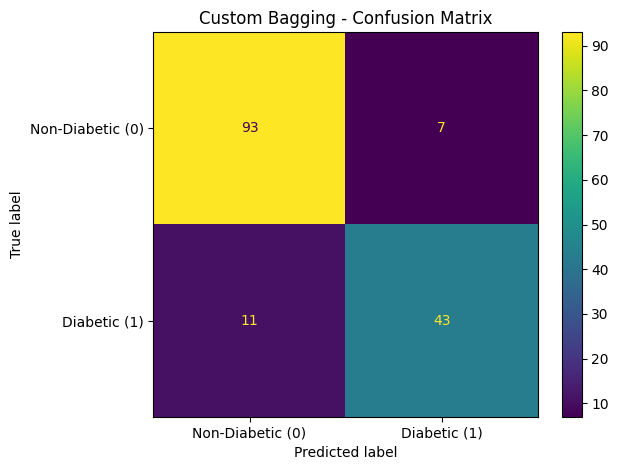

Scikit-Learn Bagging Confusion Matrix:


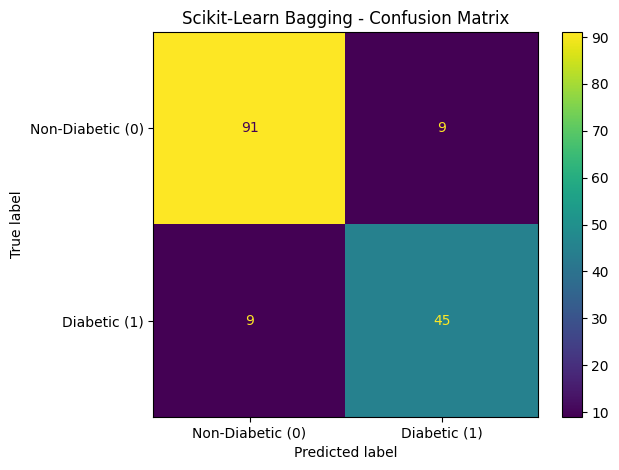


Accuracy Comparison
Custom Bagging Accuracy     : 0.8831
Scikit-Learn Bagging Accuracy: 0.8831

Accuracy Difference: 0.0000

Confusion Matrix Comparison

Custom Bagging:
[[93  7]
 [11 43]]

Scikit-Learn Bagging:
[[91  9]
 [ 9 45]]

Confusion matrices are different.
✓ Accuracy values are approximately equal.

Final Validation Summary
Number of Custom Trees       : 50
Number of Scikit-Learn Trees : 50

Custom Bagging Accuracy      : 0.8831
Scikit-Learn Bagging Accuracy: 0.8831

✓ Custom Bagging implementation is validated.


In [54]:
# ==========================================
# Task 10: Validation against Scikit-Learn's
# BaggingClassifier
# ==========================================

from sklearn.ensemble import BaggingClassifier

# ------------------------------------------
# 1. Instantiate Scikit-Learn Bagging
# ------------------------------------------

sklearn_bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(
        max_depth=None
    ),
    n_estimators=50,
    random_state=42
)


# ------------------------------------------
# 2. Train the Scikit-Learn Bagging Model
# ------------------------------------------

sklearn_bagging.fit(X_train, y_train)

print("Scikit-Learn BaggingClassifier training completed.")


# ------------------------------------------
# 3. Make Predictions
# ------------------------------------------

# Predictions using Scikit-Learn Bagging
y_pred_sklearn = sklearn_bagging.predict(X_test)

# Custom Bagging predictions from Task 7
y_pred_custom = custom_bagging_predict(
    ensemble,
    X_test
)


# ------------------------------------------
# 4. Calculate Accuracy
# ------------------------------------------

accuracy_custom = accuracy_score(
    y_test,
    y_pred_custom
)

accuracy_sklearn = accuracy_score(
    y_test,
    y_pred_sklearn
)


# ------------------------------------------
# 5. Calculate Confusion Matrices
# ------------------------------------------

cm_custom = confusion_matrix(
    y_test,
    y_pred_custom
)

cm_sklearn = confusion_matrix(
    y_test,
    y_pred_sklearn
)


# ------------------------------------------
# 6. Display Confusion Matrix - Custom
# ------------------------------------------

print("\nCustom Bagging Confusion Matrix:")

disp_custom = ConfusionMatrixDisplay(
    confusion_matrix=cm_custom,
    display_labels=["Non-Diabetic (0)", "Diabetic (1)"]
)

disp_custom.plot()
plt.title("Custom Bagging - Confusion Matrix")
plt.tight_layout()
plt.show()


# ------------------------------------------
# 7. Display Confusion Matrix - Scikit-Learn
# ------------------------------------------

print("Scikit-Learn Bagging Confusion Matrix:")

disp_sklearn = ConfusionMatrixDisplay(
    confusion_matrix=cm_sklearn,
    display_labels=["Non-Diabetic (0)", "Diabetic (1)"]
)

disp_sklearn.plot()
plt.title("Scikit-Learn Bagging - Confusion Matrix")
plt.tight_layout()
plt.show()


# ------------------------------------------
# 8. Compare Accuracy
# ------------------------------------------

print("\n==========================================")
print("Accuracy Comparison")
print("==========================================")

print(f"Custom Bagging Accuracy     : {accuracy_custom:.4f}")
print(f"Scikit-Learn Bagging Accuracy: {accuracy_sklearn:.4f}")

print(
    f"\nAccuracy Difference: "
    f"{abs(accuracy_custom - accuracy_sklearn):.4f}"
)


# ------------------------------------------
# 9. Compare Confusion Matrices Numerically
# ------------------------------------------

print("\n==========================================")
print("Confusion Matrix Comparison")
print("==========================================")

print("\nCustom Bagging:")
print(cm_custom)

print("\nScikit-Learn Bagging:")
print(cm_sklearn)


# ------------------------------------------
# 10. Validate Custom Implementation
# ------------------------------------------

if np.array_equal(cm_custom, cm_sklearn):
    print("\n✓ Confusion matrices are identical.")
else:
    print("\nConfusion matrices are different.")

if np.isclose(accuracy_custom, accuracy_sklearn):
    print("✓ Accuracy values are approximately equal.")
else:
    print("Accuracy values are different.")


# ------------------------------------------
# 11. Final Validation Summary
# ------------------------------------------

print("\n==========================================")
print("Final Validation Summary")
print("==========================================")

print(f"Number of Custom Trees       : {len(ensemble)}")
print(f"Number of Scikit-Learn Trees : {sklearn_bagging.n_estimators}")

print(f"\nCustom Bagging Accuracy      : {accuracy_custom:.4f}")
print(f"Scikit-Learn Bagging Accuracy: {accuracy_sklearn:.4f}")

if np.isclose(accuracy_custom, accuracy_sklearn):
    print("\n✓ Custom Bagging implementation is validated.")
else:
    print("\n⚠ Custom and Scikit-Learn results differ.")

### **Conclusion and Interpretation**

Students should summarize their findings by answering the following key questions:

1. **Variance and Stability:** How does the test accuracy of the Bagging ensemble compare to the single decision tree? Why does Bagging provide more consistent performance across different train-test splits?

2. **Wisdom of Crowds:** How does random resampling with replacement (bootstrapping) foster model diversity, and how does the consensus voting rule translate to a "Wisdom of Crowds" effect?

3. **Clinical Interpretation:** In predicting diabetes, why are False Negatives (predicting non-diabetic for a diabetic patient) especially costly, and how does Bagging's Recall metric help minimize this risk compared to a single decision tree?